<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/Phase2/IDW_Add_PM25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


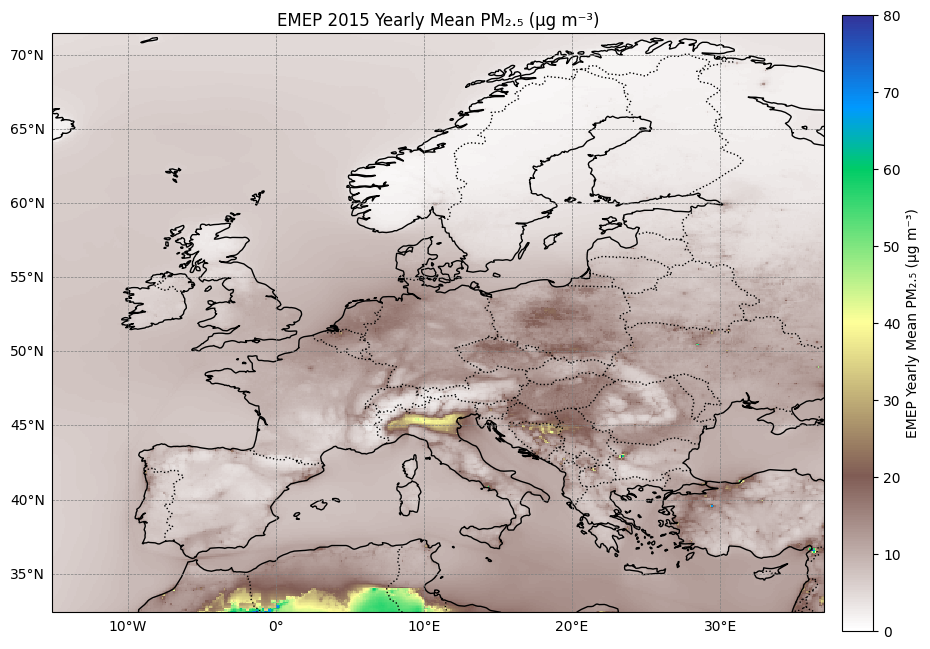

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the EMEP PM2.5 NetCDF File ===
emep_netcdf_path = "EMEP_yearly_2015.nc"
ds = xr.open_dataset(emep_netcdf_path)

# Extract PM2.5 values (μg m⁻³)
pm25 = ds["SURF_ug_PM25_rh50"].squeeze().values

# Extract coordinates
lon = ds["lon"].values
lat = ds["lat"].values

# Create 2D meshgrid
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization (adjusted for PM2.5) ===
norm = mcolors.Normalize(0, 80)

# Create map
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot PM2.5 field
mesh = ax.pcolormesh(
    Lon,
    Lat,
    pm25,
    cmap='terrain_r',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("EMEP Yearly Mean PM₂.₅ (μg m⁻³)")

# Coastlines & borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Title
ax.set_title("EMEP 2015 Yearly Mean PM₂.₅ (μg m⁻³)")

plt.show()

ds.close()

In [3]:
import xarray as xr
import pandas as pd
import numpy as np

# ======================================================
# 1 Load EMEP NetCDF
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")

lat_array = ds["lat"].values
lon_array = ds["lon"].values
pm_model = ds["SURF_ug_PM25_rh50"].isel(time=0).values  # shape (lat, lon)

# ======================================================
# 2 Load station CSV
# ======================================================
stations = pd.read_csv("yearly_PM25_2015.csv")

# Keep only stations inside EMEP domain
stations = stations[
    (stations["Latitude"] >= lat_array.min()) &
    (stations["Latitude"] <= lat_array.max()) &
    (stations["Longitude"] >= lon_array.min()) &
    (stations["Longitude"] <= lon_array.max())
].copy()

# ======================================================
# 3 Assign nearest grid cell
# ======================================================
lat_idx = np.abs(lat_array[:, None] - stations["Latitude"].values).argmin(axis=0)
lon_idx = np.abs(lon_array[:, None] - stations["Longitude"].values).argmin(axis=0)

stations["lat_idx"] = lat_idx
stations["lon_idx"] = lon_idx

stations["nearest_grid_lat"] = lat_array[lat_idx]
stations["nearest_grid_lon"] = lon_array[lon_idx]

stations["grid_cell_index"] = list(zip(
    stations["nearest_grid_lon"],
    stations["nearest_grid_lat"]
))

# ======================================================
# 4 Average stations per grid cell
# ======================================================
grid_agg = (
    stations.groupby(
        ["lon_idx", "lat_idx",
         "nearest_grid_lon", "nearest_grid_lat", "grid_cell_index"]
    )
    .agg(
        SURF_ug_PM25_rh50=("Average", "mean"),
        n_stations=("Average", "count")
    )
    .reset_index()
)

# ======================================================
# 5 Extract EMEP model value
# ======================================================
grid_agg["nearest_SURF_ug_PM25_rh50"] = [
    pm_model[i, j]
    for i, j in zip(grid_agg["lat_idx"], grid_agg["lon_idx"])
]

# ======================================================
# 6 Final structure
# ======================================================
final_df = grid_agg[[
    "nearest_grid_lon",
    "nearest_grid_lat",
    "grid_cell_index",
    "SURF_ug_PM25_rh50",
    "nearest_SURF_ug_PM25_rh50",
    "n_stations"
]]

# ======================================================
# 7 Save file
# ======================================================
final_df.to_csv("basePM25_gridcell_average.csv", index=False)

print("Done. File saved as 'basePM25_gridcell_average.csv'")
print("Total grid cells with observations:", len(final_df))


Done. File saved as 'basePM25_gridcell_average.csv'
Total grid cells with observations: 599


In [4]:
import numpy as np
import pandas as pd
import netCDF4 as nc
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import itertools
from sklearn.neighbors import BallTree

# === Load CSV Data ===
csv_file_path = "basePM25_gridcell_average.csv"
df = pd.read_csv(csv_file_path)

# Compute bias (Observed - Modeled at nearest grid)
df["bias"] = df["SURF_ug_PM25_rh50"] - df["nearest_SURF_ug_PM25_rh50"]

# === Load NetCDF Data ===
netcdf_path = "EMEP_yearly_2015.nc"
dataset = nc.Dataset(netcdf_path, "r")

lon = dataset.variables["lon"][:]
lat = dataset.variables["lat"][:]
pm25_modeled = dataset.variables["SURF_ug_PM25_rh50"][0, :, :]  # (time, lat, lon) -> [0, :, :]

# Convert degrees to radians for Haversine
lon_rad = np.radians(lon)
lat_rad = np.radians(lat)

# Grid points
lon_mesh, lat_mesh = np.meshgrid(lon_rad, lat_rad)
points_grid = np.column_stack([lat_mesh.ravel(), lon_mesh.ravel()])  # (lat, lon) σε radians

# === Station points at nearest grid cells (in radians) ===
station_points = np.column_stack([
    np.radians(df["nearest_grid_lat"].values),
    np.radians(df["nearest_grid_lon"].values)
])
bias_values = df["bias"].values

# === Grid Search for best (p, k) ===
p_values = np.arange(0.1, 5.1, 0.1).tolist()
k_values = np.arange(2, 41, 1).tolist()

kf = KFold(n_splits=10, shuffle=True, random_state=42)
results = []
best_rmse = float("inf")
best_params = None

with tqdm(total=len(p_values) * len(k_values), desc="Grid Search for IDW Additive") as pbar:
    for p, k in itertools.product(p_values, k_values):
        fold_rmses = []
        for train_index, test_index in kf.split(station_points):
            train_points, test_points = station_points[train_index], station_points[test_index]
            train_values, test_values = bias_values[train_index], bias_values[test_index]

            train_tree = BallTree(train_points, metric="haversine")
            predicted_bias = []

            for test_point in test_points:
                dists, idxs = train_tree.query([test_point], k=k)
                dists = dists.flatten()
                idxs = idxs.flatten()

                if np.any(dists == 0):
                    predicted_bias.append(train_values[idxs[dists == 0]][0])
                else:
                    weights = 1 / (dists ** p)
                    weights /= np.sum(weights)
                    interpolated_bias = np.sum(weights * train_values[idxs])
                    predicted_bias.append(interpolated_bias)

            fold_rmse = np.sqrt(mean_squared_error(test_values, predicted_bias))
            fold_rmses.append(fold_rmse)

        mean_rmse = np.mean(fold_rmses)
        results.append((p, k, mean_rmse))
        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_params = (p, k)
        pbar.update(1)

# Save Grid Search Results
results_df = pd.DataFrame(results, columns=["p", "k", "RMSE"])
results_df.to_csv("BaseCase_PM25_Y_IDW_ADD_Val.csv", index=False)
print(f"\nBest parameters found: p={best_params[0]}, k={best_params[1]} with RMSE={best_rmse:.4f}")

# === Apply IDW with Best Parameters ===
def idw_inverse_distance(grid_points, station_points, values, p, k):
    tree = BallTree(station_points, metric="haversine")
    dists, idxs = tree.query(grid_points, k=k)
    zero_dist_mask = dists == 0
    interpolated = np.zeros(grid_points.shape[0])

    interpolated[zero_dist_mask[:, 0]] = values[idxs[zero_dist_mask[:, 0], 0]]
    non_zero_idx = ~zero_dist_mask[:, 0]
    dists_non_zero = dists[non_zero_idx]
    idxs_non_zero = idxs[non_zero_idx]

    weights = 1 / (dists_non_zero ** p)
    weights /= np.sum(weights, axis=1, keepdims=True)
    interpolated[non_zero_idx] = np.sum(weights * values[idxs_non_zero], axis=1)
    return interpolated

print("\nInterpolating bias field with best hyperparameters...")
interpolated_bias = idw_inverse_distance(points_grid, station_points, bias_values, best_params[0], best_params[1])
interpolated_bias = interpolated_bias.reshape(pm25_modeled.shape)

# === Save Interpolated Bias to NetCDF ===
output_path = "BaseCase_PM25_Y_IDW_ADD.nc"
new_dataset = nc.Dataset(output_path, "w", format="NETCDF4")
new_dataset.createDimension("lat", lat.shape[0])
new_dataset.createDimension("lon", lon.shape[0])

lat_var = new_dataset.createVariable("lat", "f4", ("lat",))
lon_var = new_dataset.createVariable("lon", "f4", ("lon",))
bias_var = new_dataset.createVariable("Interpolated_Bias", "f4", ("lat", "lon"))

bias_var.setncatts(dataset.variables["SURF_ug_PM25_rh50"].__dict__)
lat_var[:] = lat
lon_var[:] = lon
bias_var[:, :] = interpolated_bias

new_dataset.description = "Interpolated Bias using Inverse Distance Weighting (Optimized p & k, Nearest Grid, Haversine BallTree)"
new_dataset.close()
print("Interpolated Bias Saved to:", output_path)

# === LOSO Validation ===
print("\nComputing LOSO RMSE, MAE, R²...")
loso_predictions = []
loso_actuals = []

for i in tqdm(range(len(station_points)), desc="LOSO Progress"):
    train_points = np.delete(station_points, i, axis=0)
    train_values = np.delete(bias_values, i)
    tree = BallTree(train_points, metric="haversine")
    test_point = station_points[i].reshape(1, -1)
    dists, idxs = tree.query(test_point, k=best_params[1])
    dists = dists.flatten()
    idxs = idxs.flatten()

    if np.any(dists == 0):
        pred = train_values[idxs[dists == 0]][0]
    else:
        weights = 1 / (dists ** best_params[0])
        weights /= np.sum(weights)
        pred = np.sum(weights * train_values[idxs])

    loso_predictions.append(pred)
    loso_actuals.append(bias_values[i])

# Metrics
loso_rmse = np.sqrt(mean_squared_error(loso_actuals, loso_predictions))
loso_mae = mean_absolute_error(loso_actuals, loso_predictions)
loso_r2 = r2_score(loso_actuals, loso_predictions)

print(f"\nLOSO RMSE: {loso_rmse:.4f}")
print(f"LOSO MAE : {loso_mae:.4f}")
print(f"LOSO R²  : {loso_r2:.4f}")

Grid Search for IDW Additive: 100%|██████████| 1950/1950 [03:58<00:00,  8.16it/s]



Best parameters found: p=1.2000000000000002, k=15 with RMSE=3.4323

Interpolating bias field with best hyperparameters...
Interpolated Bias Saved to: BaseCase_PM25_Y_IDW_ADD.nc

Computing LOSO RMSE, MAE, R²...


LOSO Progress: 100%|██████████| 599/599 [00:00<00:00, 1724.96it/s]


LOSO RMSE: 3.6658
LOSO MAE : 2.2320
LOSO R²  : 0.5136


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


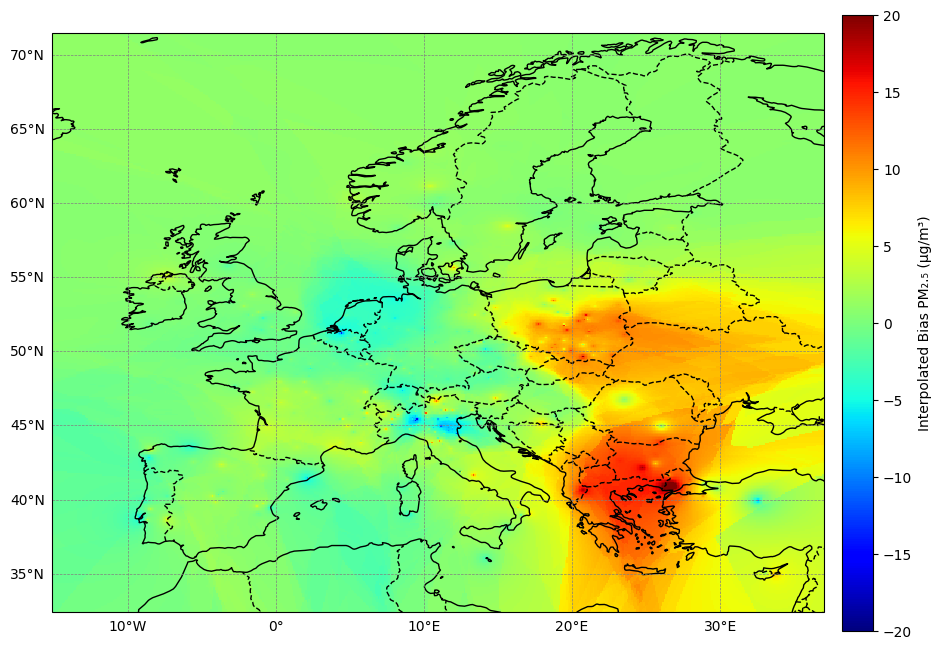

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === Load the Interpolated Bias NetCDF File ===
bias_netcdf_path = "BaseCase_PM25_Y_IDW_ADD.nc"  # File already saved
ds_bias = xr.open_dataset(bias_netcdf_path)

# Extract interpolated bias (residuals)
interpolated_bias = ds_bias["Interpolated_Bias"].squeeze().values

# Extract coordinates
lon = ds_bias["lon"].values
lat = ds_bias["lat"].values

# === Define Plot Limits (Adjust if needed) ===
cbar_min = -20  # Minimum bias value for color scale
cbar_max = 20  # Maximum bias value for color scale

# Create a plot with Cartopy
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the interpolated bias
im = ax.pcolormesh(lon, lat, interpolated_bias, transform=ccrs.PlateCarree(), cmap="jet", vmin=cbar_min, vmax=cbar_max, shading='auto')

# Add colorbar
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("Interpolated Bias PM₂.₅ (µg/m³)")

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_bias.close()

In [6]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
original_nc_path = "EMEP_yearly_2015.nc"
bias_nc_path = "BaseCase_PM25_Y_IDW_ADD.nc"
corrected_nc_path = "BaseCase_Corrected_PM25_rh50_Y_IDW_ADD.nc"

# === Load the Original Modeled PM₂.₅ NetCDF ===
with nc.Dataset(original_nc_path, "r") as original_nc, nc.Dataset(bias_nc_path, "r") as bias_nc:

    # Load model coordinates and data
    lon = original_nc.variables["lon"][:]
    lat = original_nc.variables["lat"][:]
    time = original_nc.variables["time"][:]
    pm25_original = original_nc.variables["SURF_ug_PM25_rh50"][:]

    # Load the interpolated bias
    interpolated_bias = bias_nc.variables["Interpolated_Bias"][:]

    # === Compute the Unbiased PM₂.₅ ===
    pm25_corrected = pm25_original + interpolated_bias  # Apply the bias correction

    # === Save the Corrected PM₂.₅ to a New NetCDF File ===
    with nc.Dataset(corrected_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        pm25_var = new_nc.createVariable("SURF_ug_PM25_rh50_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original PM₂.₅ variable
        pm25_var.setncatts(original_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        pm25_var[:] = pm25_corrected  # Store corrected PM₂.₅

print(" Bias correction completed successfully!")
print(" Corrected PM₂.₅ NetCDF file saved as:", corrected_nc_path)

 Bias correction completed successfully!
 Corrected PM₂.₅ NetCDF file saved as: BaseCase_Corrected_PM25_rh50_Y_IDW_ADD.nc


In [7]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "BaseCase_Corrected_PM25_rh50_Y_IDW_ADD.nc"  # Your original file
output_file = "BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2015.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_rh50_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versio

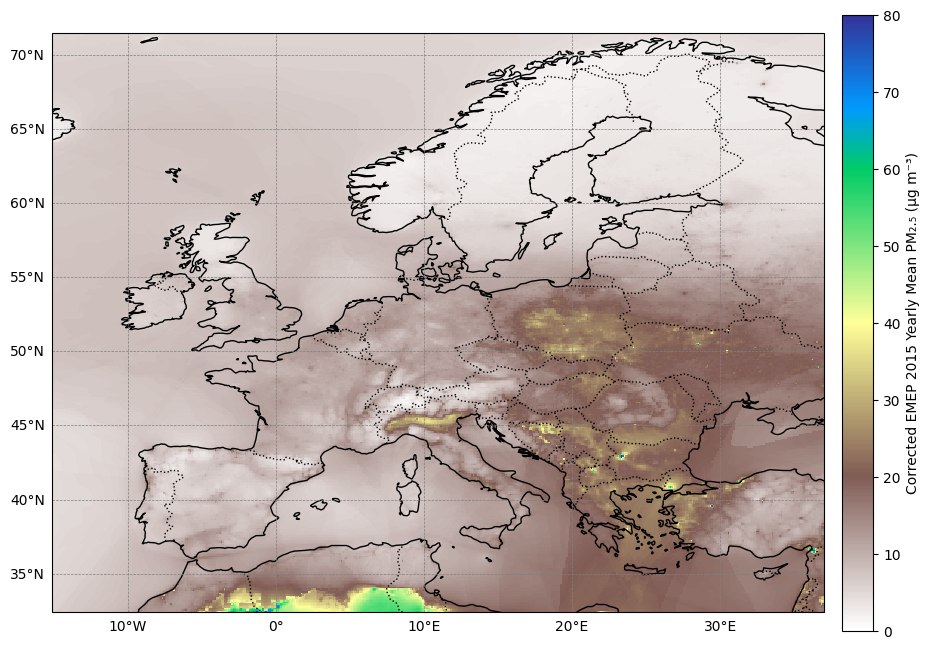

In [8]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 80)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2015 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()


# EMEP 2022

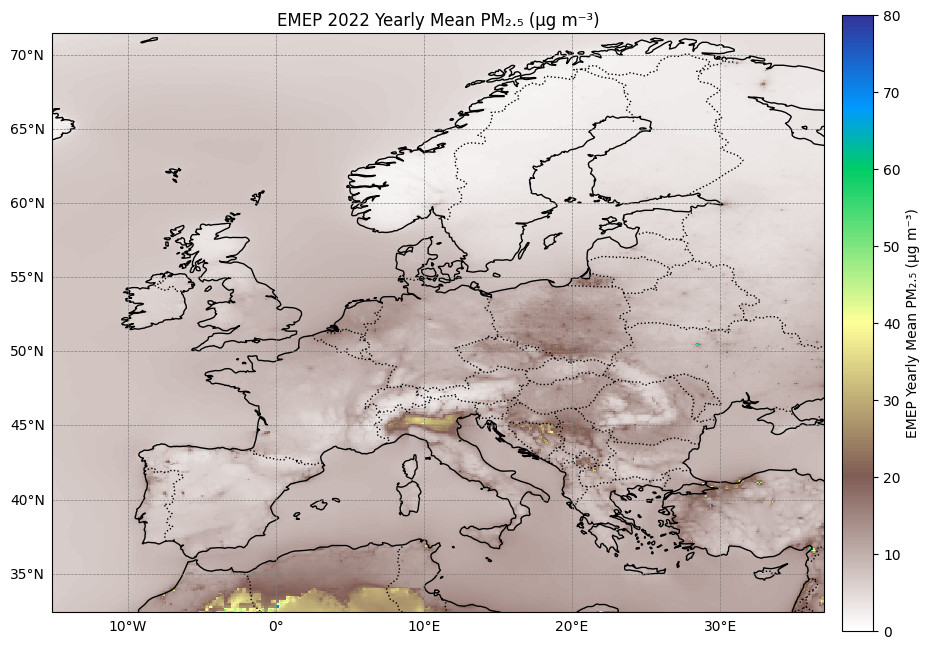

In [9]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the EMEP PM2.5 NetCDF File ===
emep_netcdf_path = "EMEP_yearly_2022.nc"
ds = xr.open_dataset(emep_netcdf_path)

# Extract PM2.5 values (μg m⁻³)
pm25 = ds["SURF_ug_PM25_rh50"].squeeze().values

# Extract coordinates
lon = ds["lon"].values
lat = ds["lat"].values

# Create 2D meshgrid
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization (adjusted for PM2.5) ===
norm = mcolors.Normalize(0, 80)

# Create map
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot PM2.5 field
mesh = ax.pcolormesh(
    Lon,
    Lat,
    pm25,
    cmap='terrain_r',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("EMEP Yearly Mean PM₂.₅ (μg m⁻³)")

# Coastlines & borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Title
ax.set_title("EMEP 2022 Yearly Mean PM₂.₅ (μg m⁻³)")

plt.show()

ds.close()

In [10]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
perturbed_scenario_nc_path = "EMEP_yearly_2022.nc"  # Perturbed scenario NetCDF
interpolated_residual_nc_path = "BaseCase_PM25_Y_IDW_ADD.nc"  # Interpolated residuals NetCDF
base_raw_nc_path = "EMEP_yearly_2015.nc"  # Raw modeled base NetCDF
corrected_scenario_nc_path = "Scenario_Corrected_PM25_Y_IDW_ADD.nc"  # Output corrected scenario NetCDF

# === Load NetCDF Data ===
with nc.Dataset(perturbed_scenario_nc_path, "r") as pert_nc, \
     nc.Dataset(interpolated_residual_nc_path, "r") as res_nc, \
     nc.Dataset(base_raw_nc_path, "r") as base_nc:

    # Load variables
    lon = pert_nc.variables["lon"][:]
    lat = pert_nc.variables["lat"][:]
    time = pert_nc.variables["time"][:]
    scenario_perturb = pert_nc.variables["SURF_ug_PM25_rh50"][:]
    interpolated_residual = res_nc.variables["Interpolated_Bias"][:]
    base_raw = base_nc.variables["SURF_ug_PM25_rh50"][:]  # This is your BC

    # === Compute the Unbiased Scenario ===
    threshold = 1e-4
    ratio = np.where(base_raw > threshold, interpolated_residual / base_raw, 0.0)
    scenario_corrected = scenario_perturb * (1 + ratio)

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        scenario_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original variable
        scenario_var.setncatts(pert_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        scenario_var[:] = scenario_corrected

print("Scenario Bias Correction Completed Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF file saved as:", corrected_scenario_nc_path)


Scenario Bias Correction Completed Successfully!
Corrected PM₂.₅ Scenario NetCDF file saved as: Scenario_Corrected_PM25_Y_IDW_ADD.nc


In [11]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected_PM25_Y_IDW_ADD.nc"  # Your original file
output_file = "Scen_2022_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2022.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")



 Correction completed! Renamed and fixed NetCDF saved as: Scen_2022_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versio

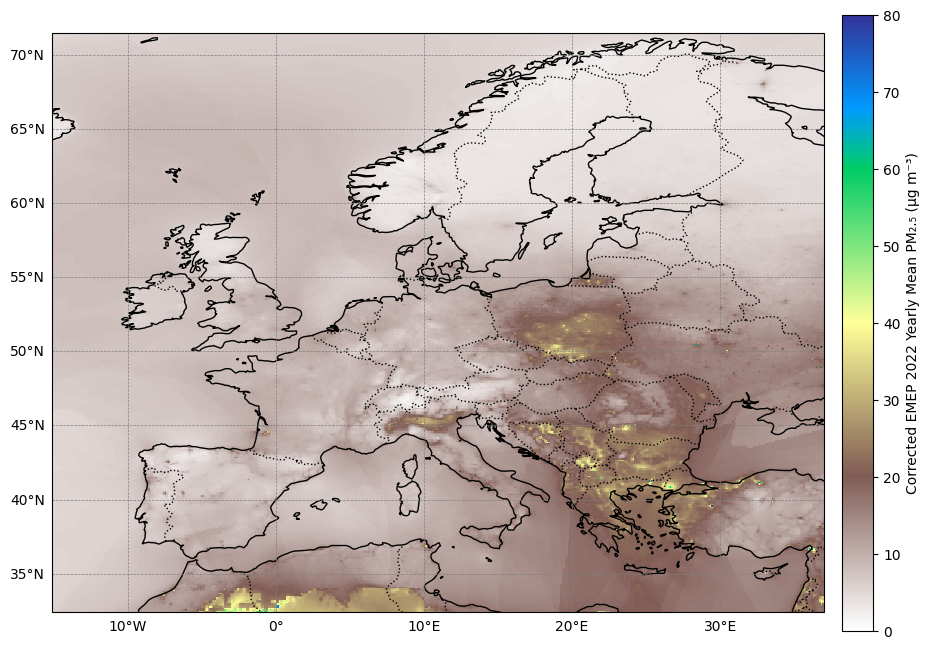

In [12]:

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_2022_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 80)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2022 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

# EMEP 2023

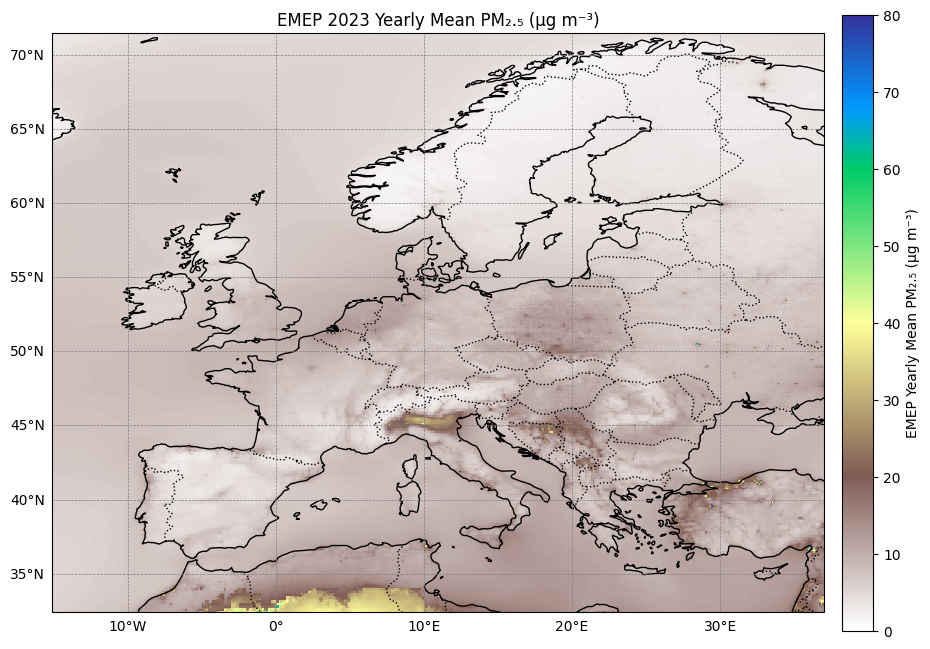

In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the EMEP PM2.5 NetCDF File ===
emep_netcdf_path = "EMEP_yearly_2023.nc"
ds = xr.open_dataset(emep_netcdf_path)

# Extract PM2.5 values (μg m⁻³)
pm25 = ds["SURF_ug_PM25_rh50"].squeeze().values

# Extract coordinates
lon = ds["lon"].values
lat = ds["lat"].values

# Create 2D meshgrid
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization (adjusted for PM2.5) ===
norm = mcolors.Normalize(0, 80)

# Create map
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot PM2.5 field
mesh = ax.pcolormesh(
    Lon,
    Lat,
    pm25,
    cmap='terrain_r',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("EMEP Yearly Mean PM₂.₅ (μg m⁻³)")

# Coastlines & borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Title
ax.set_title("EMEP 2023 Yearly Mean PM₂.₅ (μg m⁻³)")

plt.show()

ds.close()

In [14]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
perturbed_scenario_nc_path = "EMEP_yearly_2023.nc"  # Perturbed scenario NetCDF
interpolated_residual_nc_path = "BaseCase_PM25_Y_IDW_ADD.nc"  # Interpolated residuals NetCDF
base_raw_nc_path = "EMEP_yearly_2015.nc"  # Raw modeled base NetCDF
corrected_scenario_nc_path = "Scenario_Corrected3_PM25_Y_IDW_ADD.nc"  # Output corrected scenario NetCDF

# === Load NetCDF Data ===
with nc.Dataset(perturbed_scenario_nc_path, "r") as pert_nc, \
     nc.Dataset(interpolated_residual_nc_path, "r") as res_nc, \
     nc.Dataset(base_raw_nc_path, "r") as base_nc:

    # Load variables
    lon = pert_nc.variables["lon"][:]
    lat = pert_nc.variables["lat"][:]
    time = pert_nc.variables["time"][:]
    scenario_perturb = pert_nc.variables["SURF_ug_PM25_rh50"][:]
    interpolated_residual = res_nc.variables["Interpolated_Bias"][:]
    base_raw = base_nc.variables["SURF_ug_PM25_rh50"][:]  # This is your BC

    # === Compute the Unbiased Scenario ===
    threshold = 1e-4
    ratio = np.where(base_raw > threshold, interpolated_residual / base_raw, 0.0)
    scenario_corrected = scenario_perturb * (1 + ratio)

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        scenario_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original variable
        scenario_var.setncatts(pert_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        scenario_var[:] = scenario_corrected

print("Scenario Bias Correction Completed Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF file saved as:", corrected_scenario_nc_path)


Scenario Bias Correction Completed Successfully!
Corrected PM₂.₅ Scenario NetCDF file saved as: Scenario_Corrected3_PM25_Y_IDW_ADD.nc


In [15]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected3_PM25_Y_IDW_ADD.nc"  # Your original file
output_file = "Scen_2023_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2023.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")



 Correction completed! Renamed and fixed NetCDF saved as: Scen_2023_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versio

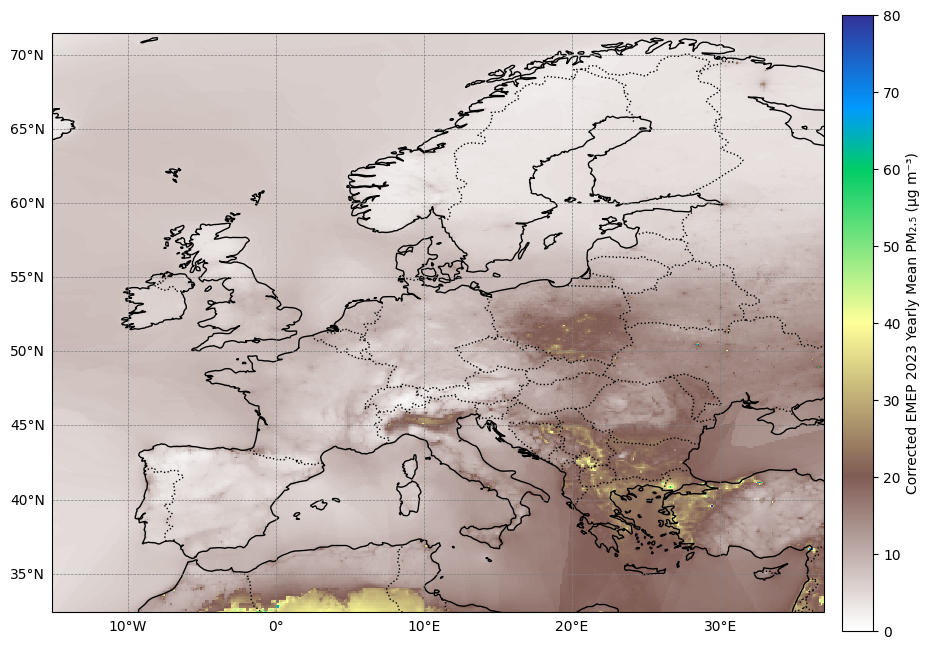

In [16]:

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_2023_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 80)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2023 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

# EMEP 2024

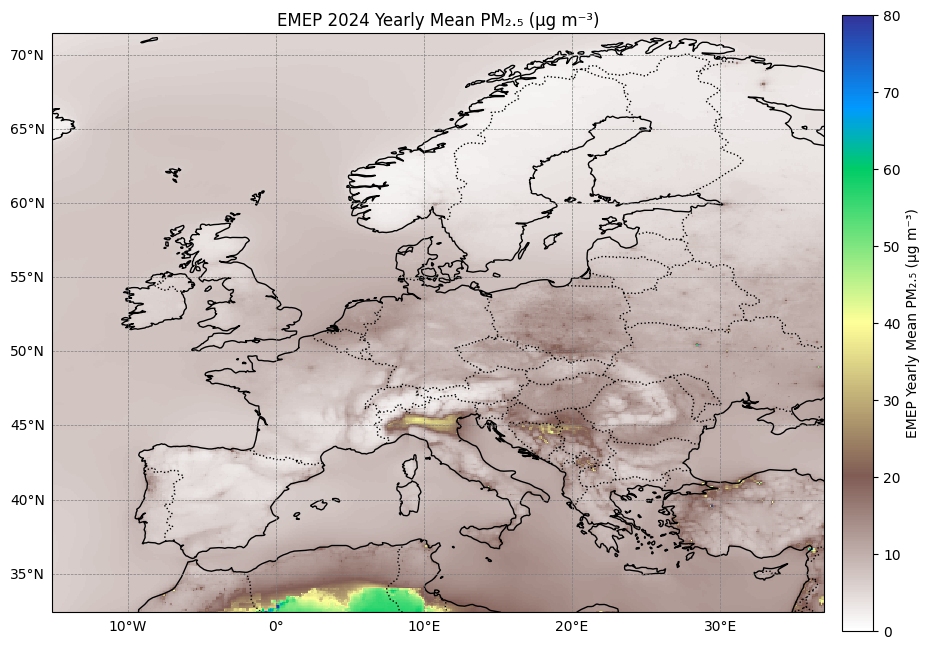

In [17]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the EMEP PM2.5 NetCDF File ===
emep_netcdf_path = "EMEP_yearly_2024.nc"
ds = xr.open_dataset(emep_netcdf_path)

# Extract PM2.5 values (μg m⁻³)
pm25 = ds["SURF_ug_PM25_rh50"].squeeze().values

# Extract coordinates
lon = ds["lon"].values
lat = ds["lat"].values

# Create 2D meshgrid
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization (adjusted for PM2.5) ===
norm = mcolors.Normalize(0, 80)

# Create map
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot PM2.5 field
mesh = ax.pcolormesh(
    Lon,
    Lat,
    pm25,
    cmap='terrain_r',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("EMEP Yearly Mean PM₂.₅ (μg m⁻³)")

# Coastlines & borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Title
ax.set_title("EMEP 2024 Yearly Mean PM₂.₅ (μg m⁻³)")

plt.show()

ds.close()

In [18]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
perturbed_scenario_nc_path = "EMEP_yearly_2024.nc"  # Perturbed scenario NetCDF
interpolated_residual_nc_path = "BaseCase_PM25_Y_IDW_ADD.nc"  # Interpolated residuals NetCDF
base_raw_nc_path = "EMEP_yearly_2015.nc"  # Raw modeled base NetCDF
corrected_scenario_nc_path = "Scenario_Corrected4_PM25_Y_IDW_ADD.nc"  # Output corrected scenario NetCDF

# === Load NetCDF Data ===
with nc.Dataset(perturbed_scenario_nc_path, "r") as pert_nc, \
     nc.Dataset(interpolated_residual_nc_path, "r") as res_nc, \
     nc.Dataset(base_raw_nc_path, "r") as base_nc:

    # Load variables
    lon = pert_nc.variables["lon"][:]
    lat = pert_nc.variables["lat"][:]
    time = pert_nc.variables["time"][:]
    scenario_perturb = pert_nc.variables["SURF_ug_PM25_rh50"][:]
    interpolated_residual = res_nc.variables["Interpolated_Bias"][:]
    base_raw = base_nc.variables["SURF_ug_PM25_rh50"][:]  # This is your BC

    # === Compute the Unbiased Scenario ===
    threshold = 1e-4
    ratio = np.where(base_raw > threshold, interpolated_residual / base_raw, 0.0)
    scenario_corrected = scenario_perturb * (1 + ratio)

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        scenario_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original variable
        scenario_var.setncatts(pert_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        scenario_var[:] = scenario_corrected

print("Scenario Bias Correction Completed Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF file saved as:", corrected_scenario_nc_path)


Scenario Bias Correction Completed Successfully!
Corrected PM₂.₅ Scenario NetCDF file saved as: Scenario_Corrected4_PM25_Y_IDW_ADD.nc


In [19]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected4_PM25_Y_IDW_ADD.nc"  # Your original file
output_file = "Scen_2024_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2024.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")



 Correction completed! Renamed and fixed NetCDF saved as: Scen_2024_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versio

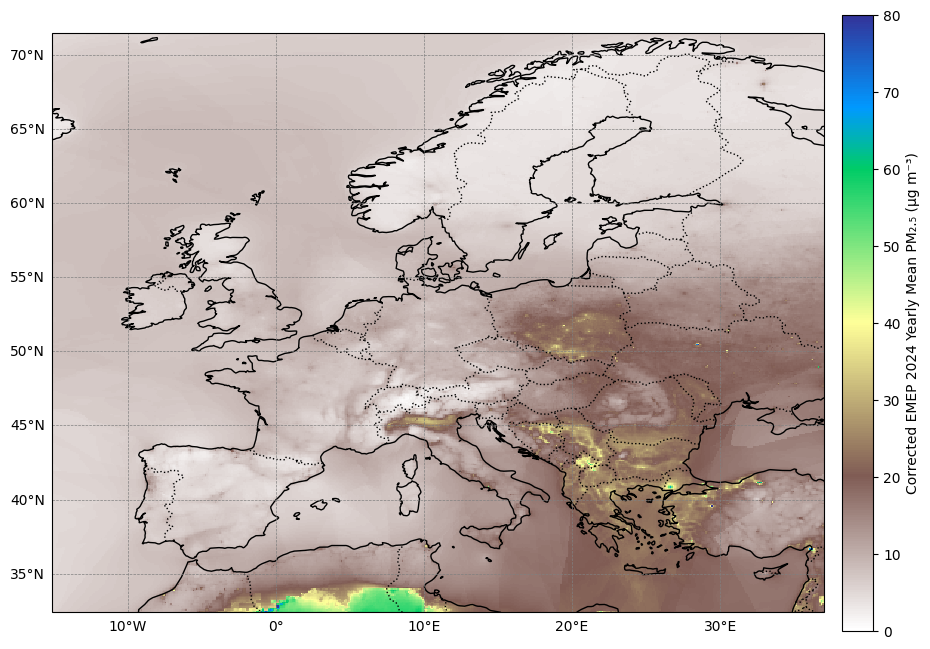

In [20]:

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_2024_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 80)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2024 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 5.258649539145988
MAE: 3.4413187849404934
Bias: -1.0608119106907434
R: 0.6669691567549353
R² (corr): 0.44484785606238947
R² (true): 0.3843458981471186

ADI
RMSE: 0.9177254435882352
MAE: 0.5746279970141783
Bias: -0.19621304373801693
R: 0.9911506338581643
R² (corr): 0.9823795789974408
R² (true): 0.981249456283874

===== COUNTRY METRICS =====
   Country   RMSE_Raw  RMSE_WDI   Bias_Raw  Bias_WDI    R2_Raw    R2_WDI    N
28      XK  11.856372  0.143499 -11.856372  0.143499       NaN       NaN    1
24      RO   4.610950  0.175652  -3.475032 -0.022172  0.772700  0.996263    3
18      LU   2.235698  0.182256   2.190796 -0.043372  0.512935  0.819874    3
17      LT   1.593971  0.226677  -1.315573  0.190011  1.000000  1.000000    2
9       EE   1.434549  0.257195  -0.906214 -0.063216  0.481903  0.987450    6
11      FI   0.617523  0.290326  -0.617523  0.290326       NaN       NaN    1
21      NO   1.972644  0.334039  -1.224

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


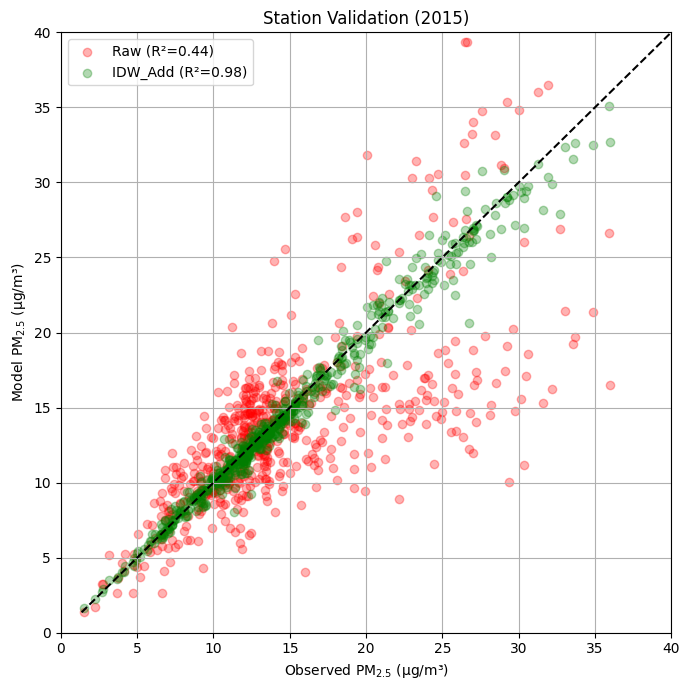

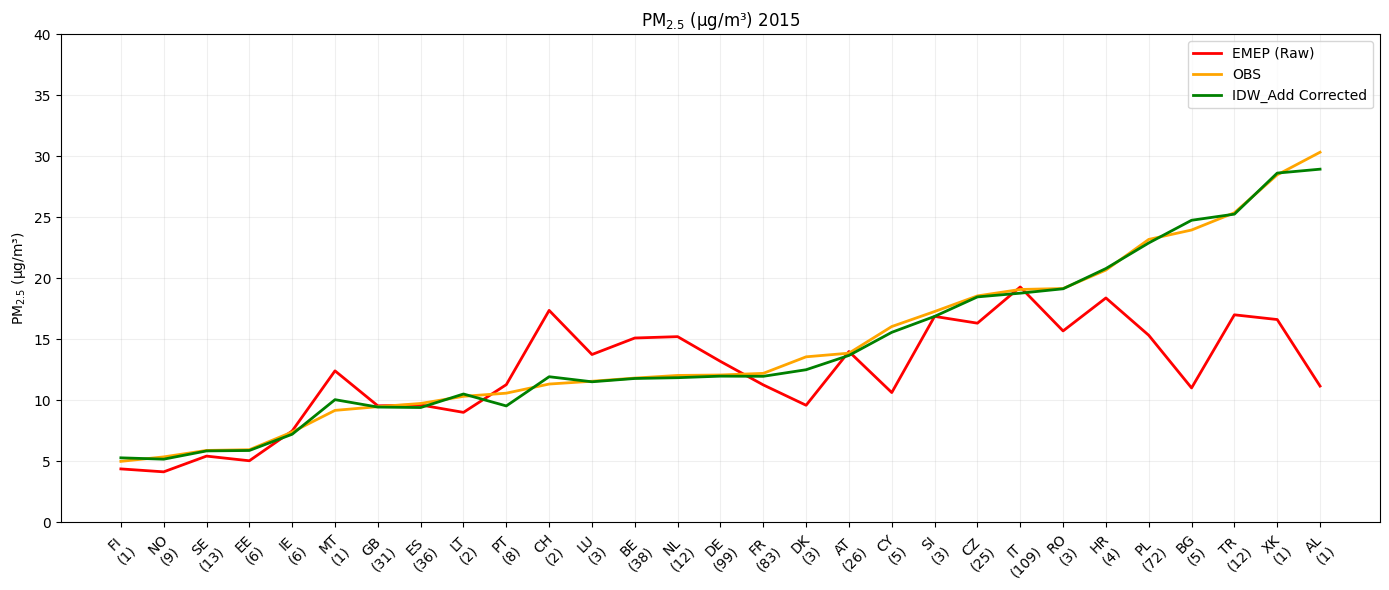

In [21]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2015.nc")
ds_wdi = xr.open_dataset("BaseCase_NKUA_PM25_CSA.Cell.Add.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2015.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Add (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM$_{2.5}$ (µg/m³)")
plt.ylabel("Model PM$_{2.5}$ (µg/m³)")
plt.title("Station Validation (2015)")
plt.xlim(0,40)
plt.ylim(0,40)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Add Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.title("PM$_{2.5}$ (µg/m³) 2015")
plt.ylim(0,40)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 3.0742667208470857
MAE: 2.346514510738826
Bias: 1.254383751264528
R: 0.816002925020796
R² (corr): 0.6658607736424947
R² (true): 0.495439071202608

ADI
RMSE: 4.1313753507996
MAE: 2.5246985901918273
Bias: 2.1875408049617033
R: 0.8590007767864625
R² (corr): 0.7378823345197459
R² (true): 0.08878714521926578

===== COUNTRY METRICS =====
   Country  RMSE_Raw   RMSE_WDI  Bias_Raw   Bias_WDI    R2_Raw    R2_WDI   N
20      SE  0.498301   0.725105  0.308085   0.507444  0.980168  0.970390   4
3       CH  3.446547   0.744032  3.366267  -0.628743  1.000000  1.000000   2
12      IE  1.080186   0.949878  0.518302   0.216514  0.594567  0.798751   4
6       DE  2.121418   0.965798  1.404922   0.494316  0.273507  0.747080  86
1       BE  3.394064   1.435003  3.254225   0.846558  0.884049  0.834357  30
15      NL  4.048195   1.455601  3.999193   1.118054  0.038777  0.012777  11
7       EE  0.973388   1.677581  0.574261   1.454682  

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


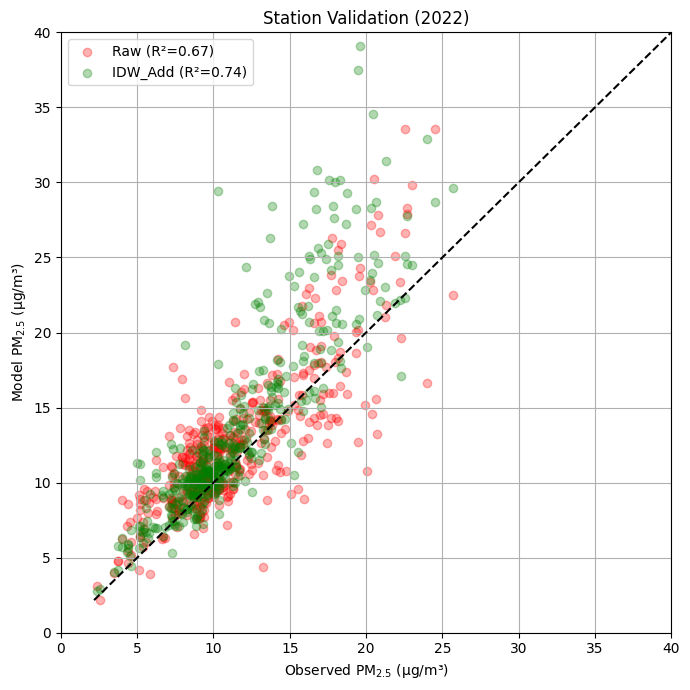

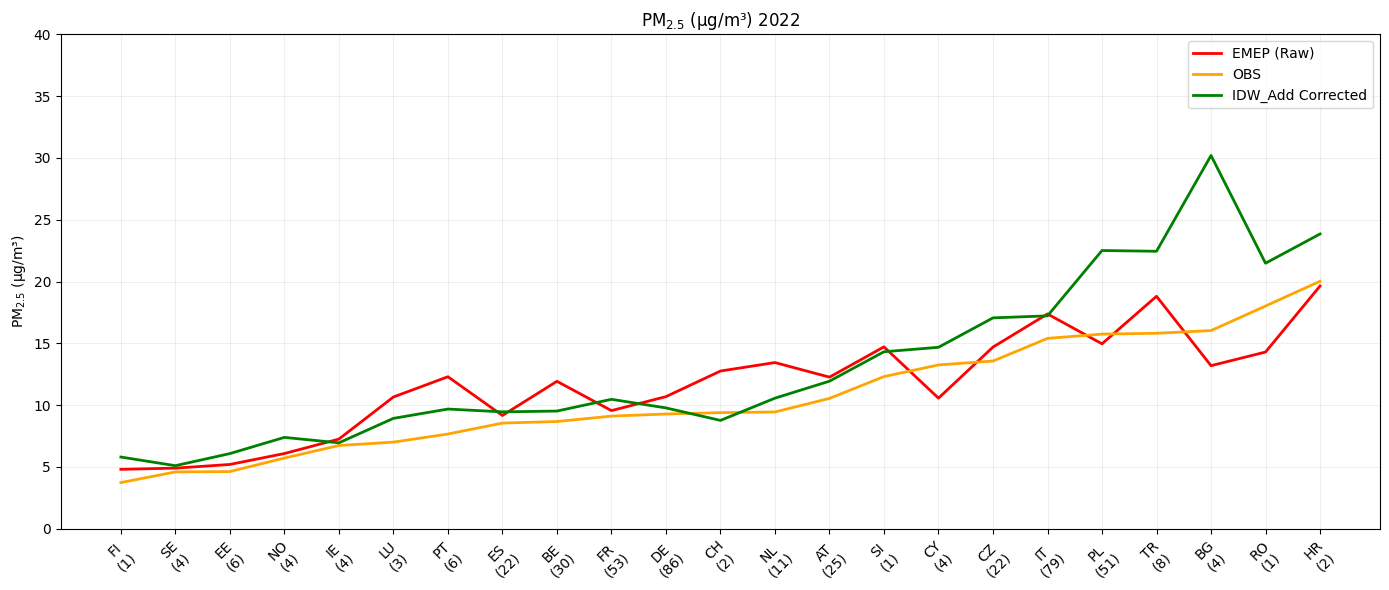

In [22]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2022.nc")
ds_wdi = xr.open_dataset("Scen_2022_NKUA_PM25_CSA.Cell.Add.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2022.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Add (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM$_{2.5}$ (µg/m³)")
plt.ylabel("Model PM$_{2.5}$ (µg/m³)")
plt.title("Station Validation (2022)")
plt.xlim(0,40)
plt.ylim(0,40)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Add Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.title("PM$_{2.5}$ (µg/m³) 2022")
plt.ylim(0,40)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 2.9468605827027425
MAE: 2.165125097721015
Bias: 0.7773300713905382
R: 0.7813692660277803
R² (corr): 0.6105379298927922
R² (true): 0.4746326738613982

ADI
RMSE: 3.513263071393595
MAE: 2.146833149762109
Bias: 1.557609854281669
R: 0.8439335479443673
R² (corr): 0.7122238333459676
R² (true): 0.2532672108908346

===== COUNTRY METRICS =====
   Country  RMSE_Raw   RMSE_WDI  Bias_Raw   Bias_WDI    R2_Raw    R2_WDI   N
3       CH  3.086469   0.274504  3.076622  -0.273352  1.000000  1.000000   2
12      IE  0.476634   0.339711  0.280882   0.017539  0.710592  0.959156   4
6       DE  1.877030   0.867534  1.088131   0.305407  0.219194  0.686672  86
20      SE  0.505869   0.960754  0.459812   0.650327  0.995148  0.878200   4
0       AT  2.191249   1.308207  0.985831   0.736175  0.323033  0.744273  25
15      NL  3.725633   1.412286  3.655523   1.088546  0.102527  0.000786  11
14      LU  2.848934   1.479608  2.819398   1.356583

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


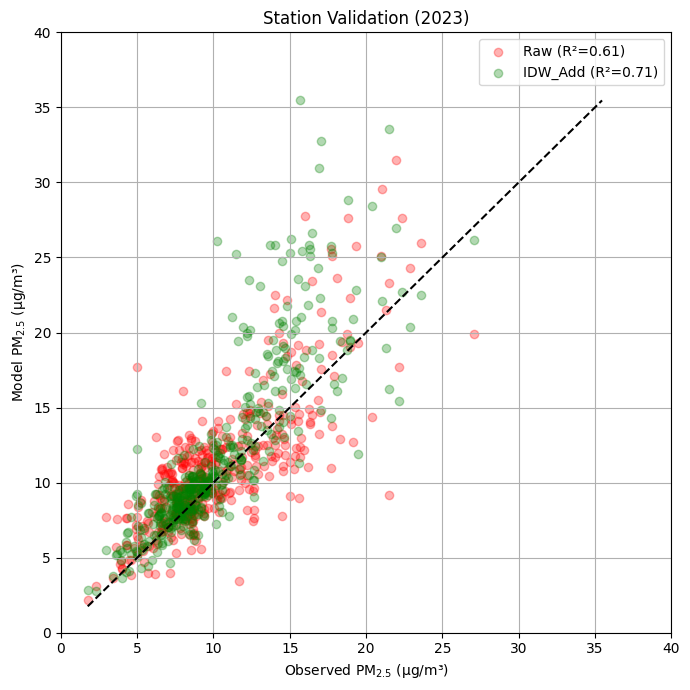

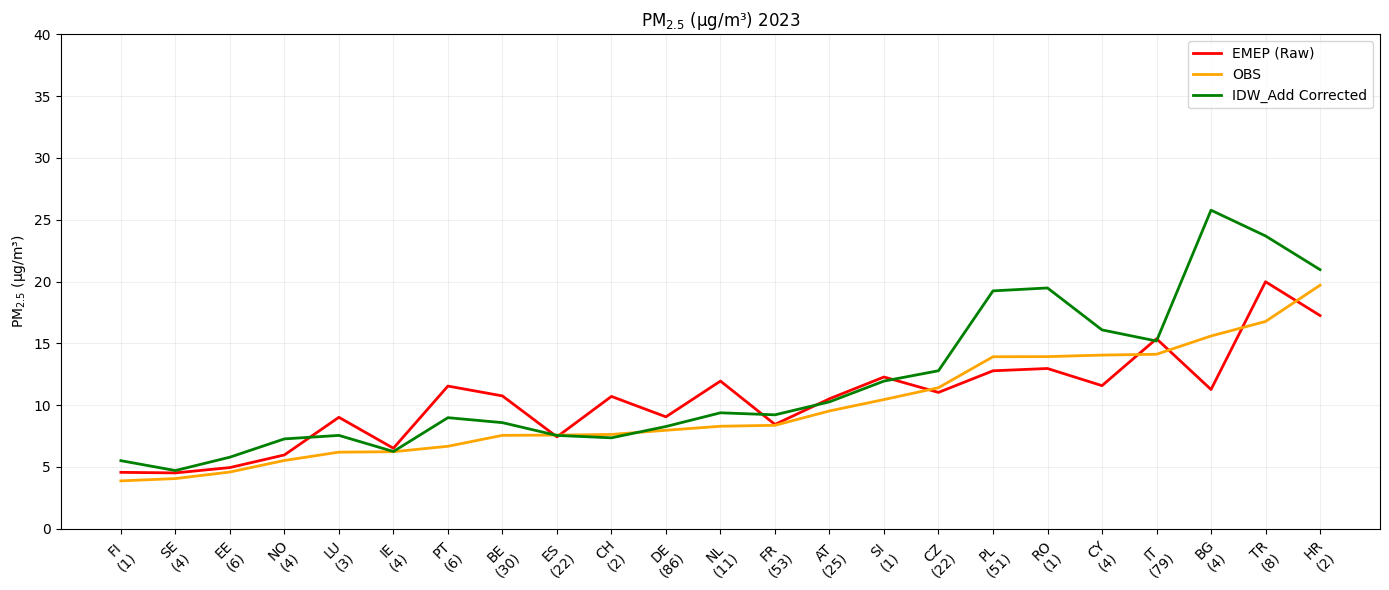

In [23]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2023.nc")
ds_wdi = xr.open_dataset("Scen_2023_NKUA_PM25_CSA.Cell.Add.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2023.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Add (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM$_{2.5}$ (µg/m³)")
plt.ylabel("Model PM$_{2.5}$ (µg/m³)")
plt.title("Station Validation (2023)")
plt.xlim(0,40)
plt.ylim(0,40)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Add Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.title("PM$_{2.5}$ (µg/m³) 2023")
plt.ylim(0,40)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 3.8510680947070632
MAE: 2.9033679138282866
Bias: 1.9934758279552327
R: 0.7663786253794099
R² (corr): 0.5873361974384339
R² (true): 0.12835636598149036

ADI
RMSE: 4.4930662960098875
MAE: 3.0630980036387454
Bias: 2.823700255926275
R: 0.8644449087526951
R² (corr): 0.7472650002684553
R² (true): -0.1864849133142743

===== COUNTRY METRICS =====
   Country  RMSE_Raw   RMSE_WDI  Bias_Raw   Bias_WDI    R2_Raw    R2_WDI   N
3       CH  4.541475   0.738108  4.522708   0.733886  1.000000  1.000000   2
12      IE  1.056765   0.800674  0.642099   0.360888  0.421718  0.801672   4
20      SE  0.771162   1.088276  0.648879   0.857754  0.990979  0.941905   4
16      NO  2.833435   1.720530  0.480642   1.377868  0.219250  0.794300   4
15      NL  4.293688   1.725845  4.188090   1.439841  0.084139  0.065924  11
6       DE  3.016868   1.738840  2.423615   1.525072  0.194634  0.744614  86
9       FI  0.777176   1.792326  0.777176   1.7

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


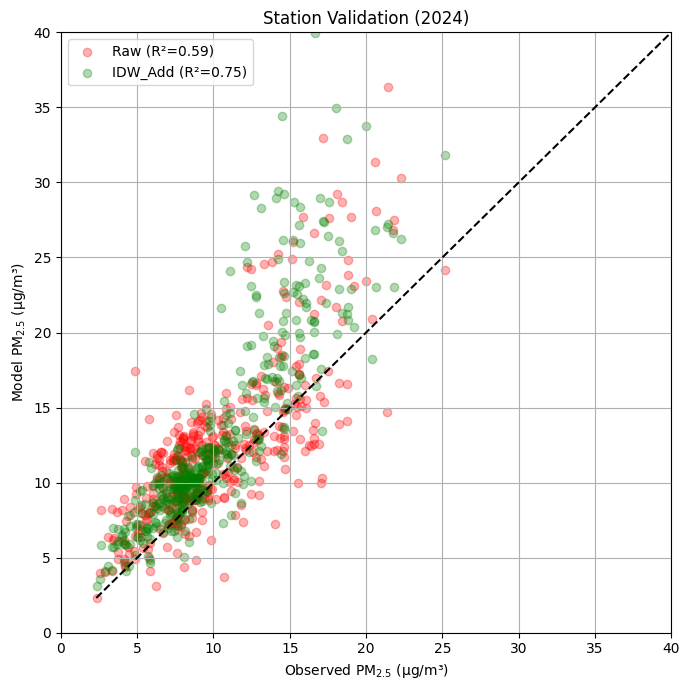

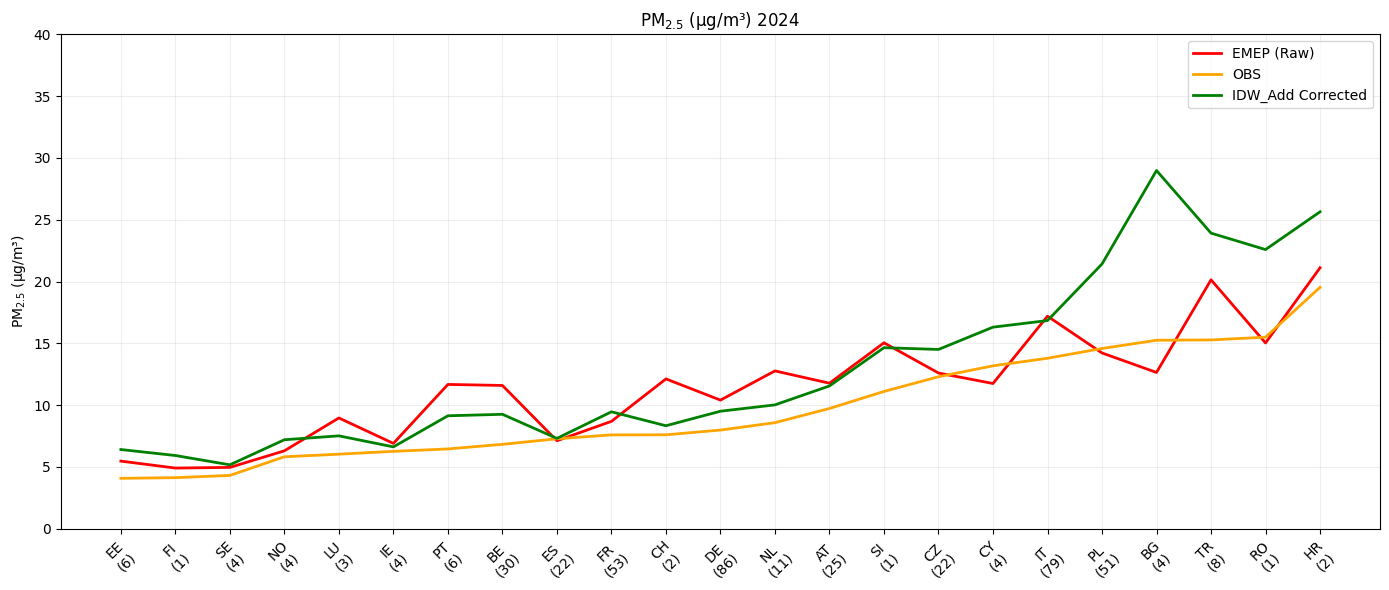

In [24]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2024.nc")
ds_wdi = xr.open_dataset("Scen_2024_NKUA_PM25_CSA.Cell.Add.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2024.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Add (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM$_{2.5}$ (µg/m³)")
plt.ylabel("Model PM$_{2.5}$ (µg/m³)")
plt.title("Station Validation (2024)")
plt.xlim(0,40)
plt.ylim(0,40)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Add Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.title("PM$_{2.5}$ (µg/m³) 2024")
plt.ylim(0,40)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
